# OMPython Example
## Electronic Filter System

This example demonstrates how to use OMPython to simulate existing OpenModelica models.



### Setup and Imports

In [2]:
from OMPython import ModelicaSystem
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

### Load and Build the FilterSystemModel

In [3]:
# Define path to the FilterSystem package
filter_system_path = Path("/home/flo/repos/SystemSimulation/examples/Modelica/FilterSystem")
package_path = filter_system_path / "package.mo"

print("Loading FilterSystem package from:", package_path)
print("Model: FilterSystem.FilterSystemModel")

Loading FilterSystem package from: /home/flo/repos/SystemSimulation/examples/Modelica/FilterSystem/package.mo
Model: FilterSystem.FilterSystemModel


In [4]:
# Load the FilterSystemModel
model_system = ModelicaSystem(str(package_path), "FilterSystem.FilterSystemModel")
print("Model loaded successfully")


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.

Model loaded successfully


In [5]:
# Build the model
print("Building model...")
model_system.buildModel()
print("Model built successfully")

Building model...

Model built successfully


### Inspect Model Information

In [6]:
# Get model information
print("Model Information:")
print("-" * 30)

outputs = model_system.getOutputs()
inputs = model_system.getInputs()
parameters = model_system.getParameters()
continuous = model_system.getContinuous()

print(f"Outputs:    {outputs}")
print(f"Inputs:     {inputs}")
print(f"Parameters: {parameters}")
print(f"Continuous: {continuous}")

Model Information:
------------------------------
Outputs:    {}
Inputs:     {}
Parameters: {'bpf.C': '0.0253', 'bpf.IL0': '0.0', 'bpf.L': '1.0', 'bpf.R': '1.26', 'lpf1.C': '0.001', 'lpf1.R': '1000.0', 'lpf1.U_out0': '0.0', 'lpf2.C': '0.001', 'lpf2.R': '1000.0', 'lpf2.U_out0': '0.0', 'src.A1': '60.0', 'src.A2': '5.0', 'src.f1': '0.159', 'src.f2': '7.96'}
Continuous: {'bpf.IL': None, 'bpf.U_in': None, 'lpf1.U_out': None, 'der(bpf.IL)': None, 'der(bpf.U_in)': None, 'der(lpf1.U_out)': None, 'der(lpf2.U_out)': None, '$cse1': None, '$cse2': None, 'bpf.I_C': None, 'bpf.I_R': None, 'bpf.dU_dt': None, 'bpf_current': None, 'lpf2.U_out': None, 'src.s1': None, 'src.s2': None, 'src_voltage': None, 'bpf.I': None, 'bpf_inductor_current': None, 'lpf1.U_in': None, 'lpf1_voltage': None, 'lpf2.U_in': None, 'lpf2_voltage': None, 'src.U_in': None}


### Configure Simulation Parameters

In [7]:
# Set simulation parameters
simulation_options = [
    "startTime=0.0",
    "stopTime=10.0",        
    "stepSize=0.002",
    "tolerance=1e-6"
]

model_system.setSimulationOptions(simulation_options)
current_options = model_system.getSimulationOptions()
print(f"Simulation options: {current_options}")

Simulation options: {'startTime': '0.0', 'stopTime': '10.0', 'stepSize': '0.002', 'tolerance': '1e-6', 'solver': 'dassl', 'outputFormat': 'mat'}


### Run Simulation

In [8]:
# Run simulation
print("Running simulation...")
model_system.simulate()
print("✓ Simulation completed successfully")

Running simulation...
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
✓ Simulation completed successfully


### Extract Results

In [9]:
# Get results (matching the monitoring variables from FilterSystemModel)
print("Extracting results...")

time_vals, src_voltage = model_system.getSolutions(["time", "src_voltage"])
_, lpf1_voltage = model_system.getSolutions(["time", "lpf1_voltage"])
_, lpf2_voltage = model_system.getSolutions(["time", "lpf2_voltage"])
_, bpf_current = model_system.getSolutions(["time", "bpf_current"])
_, bpf_inductor_current = model_system.getSolutions(["time", "bpf_inductor_current"])

print(f"✓ Results extracted: {len(time_vals)} time points")
print(f"Time range: {time_vals[0]:.3f} to {time_vals[-1]:.3f} seconds")
print(f"Time step: {(time_vals[-1] - time_vals[0]) / (len(time_vals) - 1):.4f} seconds")

Extracting results...
✓ Results extracted: 5002 time points
Time range: 0.000 to 10.000 seconds
Time step: 0.0020 seconds


### Plot Results
#### Replicating the Python plot_config structure

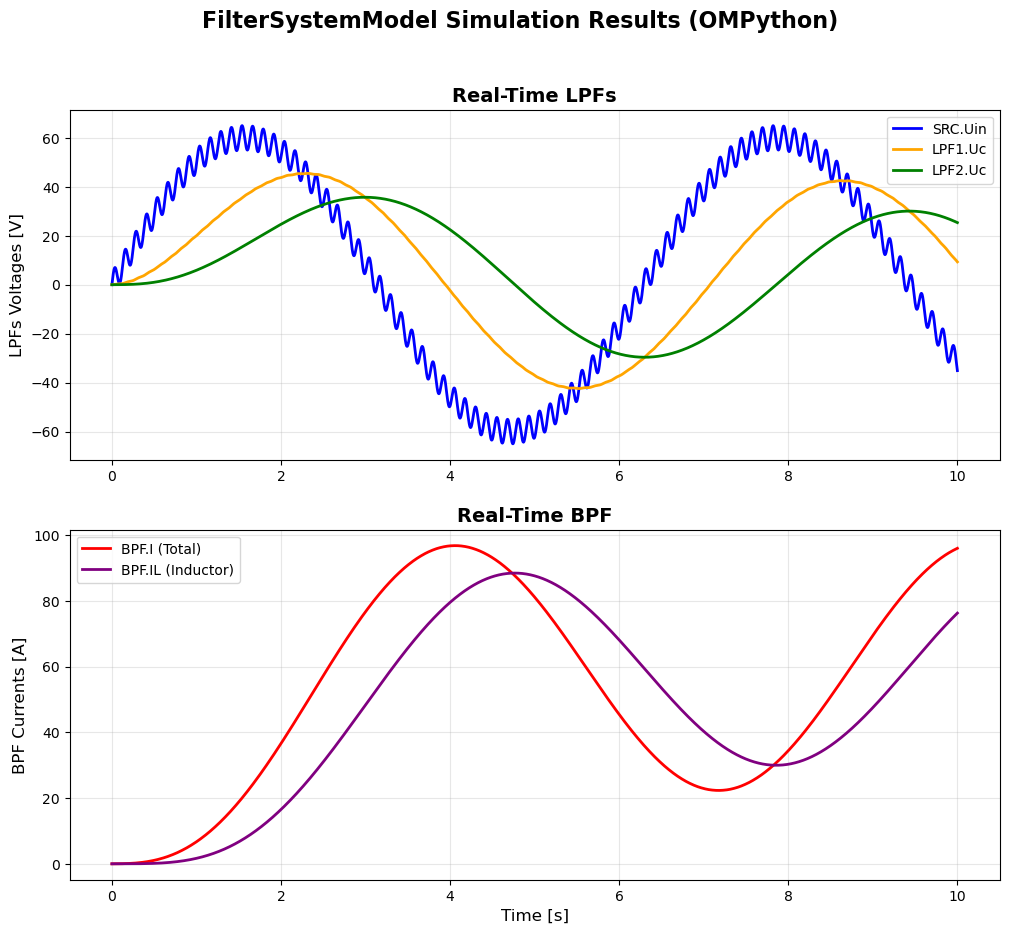

In [10]:
# Create plots matching the Python plot_config groups
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Group 1: Real-Time LPFs (voltages)
ax1.plot(time_vals, src_voltage, label='SRC.Uin', linewidth=2, color='blue')
ax1.plot(time_vals, lpf1_voltage, label='LPF1.Uc', linewidth=2, color='orange')
ax1.plot(time_vals, lpf2_voltage, label='LPF2.Uc', linewidth=2, color='green')

ax1.set_title("Real-Time LPFs", fontsize=14, fontweight='bold')
ax1.set_ylabel("LPFs Voltages [V]", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Group 2: Real-Time BPF (currents)  
ax2.plot(time_vals, bpf_current, label='BPF.I (Total)', linewidth=2, color='red')
ax2.plot(time_vals, bpf_inductor_current, label='BPF.IL (Inductor)', linewidth=2, color='purple')

ax2.set_title("Real-Time BPF", fontsize=14, fontweight='bold')
ax2.set_ylabel("BPF Currents [A]", fontsize=12)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle("FilterSystemModel Simulation Results (OMPython)", 
            fontsize=16, fontweight='bold', y=0.98)

plt.show()